# Data-Driven Selection of Foreign Books for Czech Translation

**The task.** Predict which foreign books Czech publishers will pick for translation. The model learns from past acquisitions: foreign books that *were* translated into Czech (found in the National Library catalogue, NKC) versus comparable foreign books that were not.

**This notebook** builds the complete dataset end to end and contains all the accompanying analysis (statistics, graphs, sanity checks). Heavy steps live in small scripts under `src/` and are executed from here; slow steps are skipped automatically if their output already exists (pass `force=True` to rerun).

**Data sources**

| Source | What | Role |
|---|---|---|
| **NKC** | Czech National Library MARC21 catalogue (~10 GB XML) | which foreign books WERE translated (label) |
| **Goodreads** | 2017 UCSD dump: ~2.3M books (9 GB) + ~15M reviews (15 GB) | reader-community features of the *original* editions |
| **SCKN** | Czech weekly bestseller charts (scraped) | kept on disk for a possible bonus chapter; **not used** in this dataset |

**Leakage rule (applies everywhere):** every feature must be computable *before* the acquisition decision. Each row gets a `cutoff_year`; review-derived features count only reviews dated strictly before it. Goodreads 2017 snapshot totals (`ratings_count_2017`) are metadata only, never features.

In [1]:
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
assert (REPO / "src").exists(), f"run from repo root or notebooks/: {REPO}"
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

plt.rcParams["figure.figsize"] = (9, 3.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def run_step(script: str, outputs: list[str], force: bool = False) -> None:
    """Run a pipeline script unless all its outputs already exist."""
    missing = [o for o in outputs if not (REPO / o).exists()]
    if not force and not missing:
        print(f"SKIP {script} — outputs exist")
        return
    print(f"RUN  {script}" + (f" — missing: {missing}" if missing else " (forced)"))
    subprocess.run([sys.executable, str(REPO / script)], check=True, cwd=REPO)


print(f"Repo: {REPO}")

Repo: /home/firstone/Bachelors-thesis


## Step 1 — Parse the NKC catalogue

`src/data/parse_nkc.py` streams the ~10 GB MARC21 XML dump and extracts every record that is a **translation into Czech**: author, Czech title, original title (MARC 240$a), publication year, ISBNs, source language, genre.

Output: `data/interim/nkc_translations.csv` (~225k records).

In [2]:
run_step("src/data/parse_nkc.py", ["data/interim/nkc_translations.csv"])

nkc = pd.read_csv(REPO / "data/interim/nkc_translations.csv", dtype=str, keep_default_na=False)
print(f"{len(nkc):,} translation records | columns: {nkc.columns.tolist()}")
nkc.head(3)

SKIP src/data/parse_nkc.py — outputs exist


225,483 translation records | columns: ['nkc_id', 'oclc', 'czech_isbn', 'czech_title', 'original_title', 'original_isbn', 'original_sysnum', 'author', 'secondary_authors', 'czech_pub_year', 'source_lang', 'genres']


,nkc_id,oclc,czech_isbn,czech_title,original_title,original_isbn,original_sysnum,author,secondary_authors,czech_pub_year,source_lang,genres
0,ck8300101,85541487,,O vzdělání lidu,Direktivy VKP (b) i postanovlenija sovetskogo ...,,,"Lunačarskij, Anatolij Vasil'jevič","Kyrášek, Jiří|Tuček, Alexandr",1982,rus,výbory
1,ck8300109,39561173,,Metodická příručka k učebnici Chemie pro 7. ro...,Metodická príručka na vyučovanie chémie v 7. r...,,,"Adamkovič, Emil","Berka, Ivan|Černá, Břetislava",1982,slo,metodické příručky
2,ck8300119,39561436,,Chemie pro 9. ročník zvláštní školy,Chémia pre 9. ročník osobitných škol,,,"Ďuriška, Augustín","Mandzjuk, Peter|Salamon, Zoltán|Jansa, Jaroslav",1982,slo,učebnice základních škol


### Analysis — what does the NKC translation corpus look like?

Three things matter downstream:

1. **Volume per year** — how much labeling material each cohort year has.
2. **Source languages** — what "foreign book" means in practice for the Czech market.
3. **Original-title coverage** — the matching cascade needs the original title; records without it can never match (this is the hard ceiling on match rate).

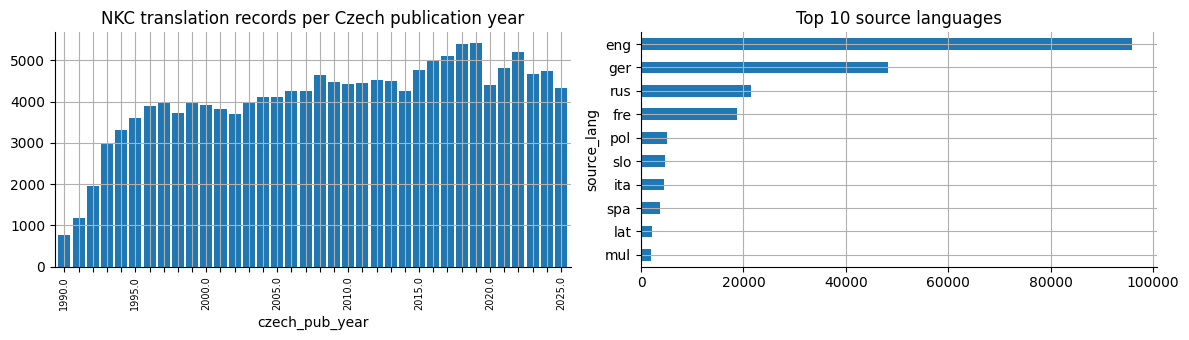

Records with an original title: 140,679 / 225,483 (62.4%)  ← hard ceiling for matching


In [3]:
year = pd.to_numeric(nkc["czech_pub_year"], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
year[year.between(1990, 2025)].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], width=0.85)
axes[0].set_title("NKC translation records per Czech publication year")
axes[0].tick_params(axis="x", labelsize=7)
for i, lbl in enumerate(axes[0].get_xticklabels()):
    lbl.set_visible(i % 5 == 0)

nkc["source_lang"].str.strip().str.lower().replace("", "<missing>").value_counts().head(10)\
    .plot(kind="barh", ax=axes[1])
axes[1].invert_yaxis()
axes[1].set_title("Top 10 source languages")
plt.tight_layout()
plt.show()

has_orig = nkc["original_title"].str.strip().str.len() > 0
print(f"Records with an original title: {has_orig.sum():,} / {len(nkc):,} "
      f"({has_orig.mean():.1%})  ← hard ceiling for matching")

## Step 2 — Build Goodreads lookup indexes

`src/data/build_goodreads_lookup.py` streams the Goodreads books dump once and writes seven lookup JSONs (author/title indexes for the matching cascade, `work_to_books` for edition grouping, `book_details` for tie-breaking). All keys are normalized with `src/matching/text_utils.normalize()` (NFKD diacritics fold + lowercase). **Never** change `normalize()` without rerunning this step.

Slow (~30 min) — skipped if outputs exist.

In [4]:
run_step(
    "src/data/build_goodreads_lookup.py",
    [
        "data/interim/goodreads_by_author_title.json",
        "data/interim/goodreads_work_to_books.json",
        "data/interim/goodreads_book_details.json",
    ],
)

SKIP src/data/build_goodreads_lookup.py — outputs exist


## Step 3 — Match NKC records to Goodreads (the hard part)

An NKC record and a Goodreads book share **no common identifier** — different ISBNs (Czech vs. original edition), different scripts/diacritics. `src/matching/build_matched_dataset.py` runs a 3-layer cascade per NKC record (first hit wins):

1. **Layer 1** — author exact + original title exact (both normalized)
2. **Layer 2** — author exact + title fuzzy (`token_set_ratio >= 88`)
3. **Layer 3** — author fuzzy (`>= 85`) + title exact

Ties are broken by Goodreads `work_id`: language match → pub-year proximity → ratings count.

Slow (~30 min) — skipped if `matched_dataset.csv` exists.

In [5]:
run_step("src/matching/build_matched_dataset.py", ["data/interim/matched_dataset.csv"])

matched = pd.read_csv(REPO / "data/interim/matched_dataset.csv", dtype=str, keep_default_na=False)
print(f"{len(matched):,} NKC records processed by the cascade")

SKIP src/matching/build_matched_dataset.py — outputs exist


225,483 NKC records processed by the cascade


### Analysis — match rate and where matches come from

The overall ~25% match rate looks low, but the ceiling is the ~62% original-title coverage from Step 1, and unmatched records skew toward obscure titles. Watch two things:

- **Layer composition** — L1 (exact/exact) should dominate; fuzzy layers are the risky ones and were manually spot-checked (≤ 2/20 wrong per layer).
- **Match rate by year** — if matching degraded over time, labels would be biased against recent books.

Overall match rate: 24.8%
match_layer
unmatched    169500
1             39376
2             13265
3              3342


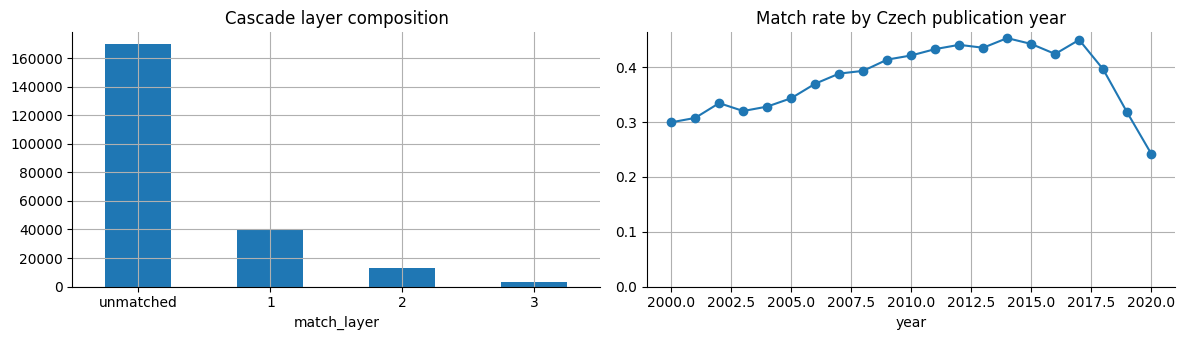

Unique matched Goodreads works: 39,097


In [6]:
layer = matched["match_layer"].replace("", "unmatched")
counts = layer.value_counts()
match_rate = 1 - counts.get("unmatched", 0) / len(matched)
print(f"Overall match rate: {match_rate:.1%}")
print(counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
counts.plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("Cascade layer composition")

yr = pd.to_numeric(matched["czech_pub_year"], errors="coerce")
is_matched = layer != "unmatched"
by_year = pd.DataFrame({"year": yr, "matched": is_matched}).dropna()
by_year = by_year[by_year["year"].between(2000, 2020)]
by_year.groupby("year")["matched"].mean().plot(ax=axes[1], marker="o")
axes[1].set_title("Match rate by Czech publication year")
axes[1].set_ylim(0, None)
plt.tight_layout()
plt.show()

n_works = matched.loc[matched["gr_work_id"].str.len() > 0, "gr_work_id"].nunique()
print(f"Unique matched Goodreads works: {n_works:,}")

## Step 4 — Build the candidate pool (all foreign works, translated or not)

To model "will this book be picked?", the dataset needs books that were **not** picked. `src/data/build_candidate_pool.py` streams the Goodreads dump and emits one row per **work** (editions aggregated; most-rated edition is the representative):

- filter: ≥ 50 ratings (2017, work-level) — an *existence* floor, not a feature
- filter: publication year 1950–2017; Czech/Slovak-language works excluded
- genre shelf shares use a **genre-only denominator** (not diluted by `to-read`/`owned`)

Slow (~20–30 min) — skipped if `candidate_pool.csv` exists.

In [7]:
run_step("src/data/build_candidate_pool.py", ["data/interim/candidate_pool.csv"])

pool = pd.read_csv(REPO / "data/interim/candidate_pool.csv", dtype={"work_id": str, "rep_book_id": str})
print(f"{len(pool):,} works in the candidate pool")
pool.head(3)

SKIP src/data/build_candidate_pool.py — outputs exist


452,824 works in the candidate pool


,work_id,rep_book_id,title,language,pub_year,n_editions,ratings_count_2017,text_reviews_2017,shelf_fiction,shelf_mystery,shelf_romance,shelf_scifi,shelf_nonfiction,shelf_ya,shelf_classics
0,1323437,25717,Good Harbor,eng,2001,7,6202,736,0.9091,0.0000,0.0909,0.0000,0.0,0.0,0.0
1,8948723,7327624,"The Unschooled Wizard (Sun Wolf and Starhawk, ...",eng,1987,1,140,7,0.2857,0.0000,0.0000,0.7143,0.0,0.0,0.0
2,6243154,6066819,Best Friends Forever,eng,2009,10,53117,3488,0.3700,0.0083,0.6217,0.0000,0.0,0.0,0.0


### Analysis — pool composition

The pool defines the model's universe: what it can and cannot rank. Check that it is dominated by plausible acquisition candidates (English-language, contemporary, reasonably popular) and that the popularity distribution has the expected heavy tail.

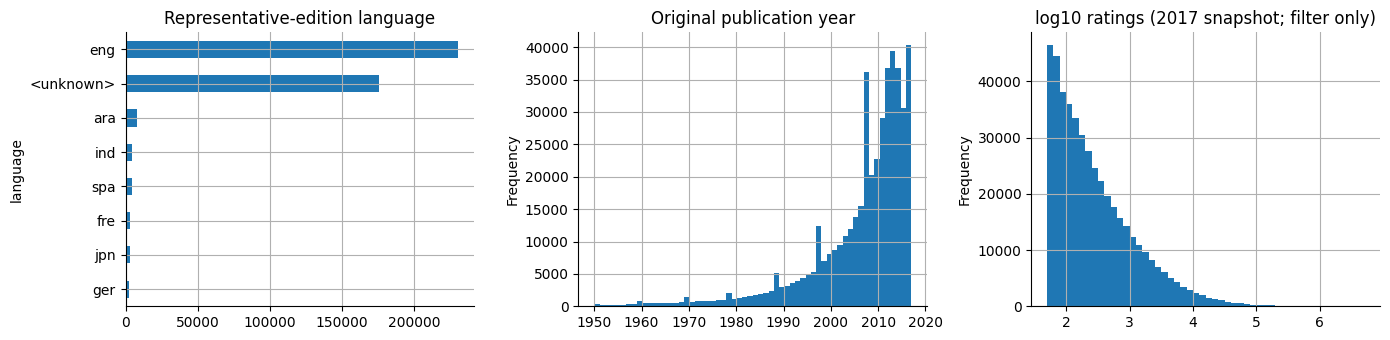

Mean genre shares (genre-only denominator):
shelf_nonfiction    0.251
shelf_fiction       0.219
shelf_romance       0.156
shelf_scifi         0.123
shelf_ya            0.103
shelf_mystery       0.090
shelf_classics      0.019


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

pool["language"].fillna("<unknown>").replace("", "<unknown>").value_counts().head(8)\
    .plot(kind="barh", ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_title("Representative-edition language")

pool["pub_year"].plot(kind="hist", bins=60, ax=axes[1])
axes[1].set_title("Original publication year")

np.log10(pool["ratings_count_2017"].clip(lower=1)).plot(kind="hist", bins=50, ax=axes[2])
axes[2].set_title("log10 ratings (2017 snapshot; filter only)")
plt.tight_layout()
plt.show()

shelf_cols = [c for c in pool.columns if c.startswith("shelf_")]
print("Mean genre shares (genre-only denominator):")
print(pool[shelf_cols].mean().round(3).sort_values(ascending=False).to_string())

## Step 5 — Labels and temporal cutoffs

`src/features/build_translation_dataset.py` joins the pool with the NKC matches:

- **positive** (`translated_cz = 1`): work first translated into Czech in **2008–2017**; `cutoff_year` = that year. (2008, not earlier: Goodreads launched in 2007 — earlier years have structurally zero pre-cutoff signal.)
- works translated before 2008 / after 2017 are **dropped** (not candidates / censored)
- **negative**: never matched to any NKC translation; `cutoff_year` sampled from the positives' year distribution (restricted to years after the book's publication) so both classes see comparable feature windows

**Honest caveat:** only ~25% of NKC records match to Goodreads, so some "negatives" were actually translated. The popularity floor mitigates (popular books match at ~2× the base rate); negative-label noise remains this dataset's main limitation.

In [9]:
run_step("src/features/build_translation_dataset.py", ["data/interim/translation_labels.csv"])

labels = pd.read_csv(REPO / "data/interim/translation_labels.csv", dtype={"work_id": str, "rep_book_id": str})
n_pos = int(labels["translated_cz"].sum())
print(f"{len(labels):,} rows | {n_pos:,} positives ({n_pos / len(labels):.2%})")

SKIP src/features/build_translation_dataset.py — outputs exist


419,716 rows | 11,274 positives (2.69%)


### Analysis — label structure

- **Positives per year** shows how acquisition volume evolved; it also drives the negatives' pseudo-cutoff distribution.
- **Language of positives vs. pool** shows what Czech publishers actually pick — expect English to dominate even more among positives than in the pool.
- **Popularity contrast** (2017 snapshot, audit only — not a feature) is a first sanity check that the label carries signal at all: translated books should be visibly more popular.

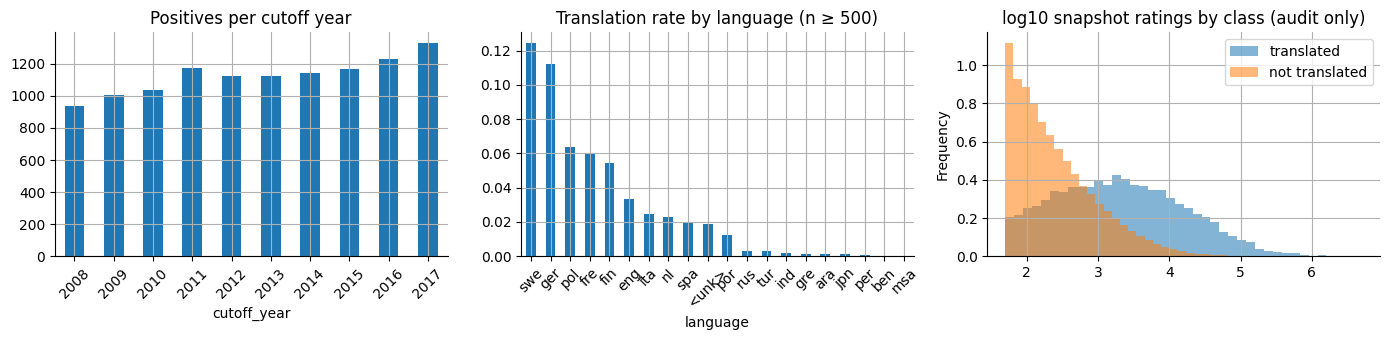

            size    mean
language                
swe         1189  0.1245
ger         2369  0.1123
pol          897  0.0635
fre         2918  0.0603
fin          951  0.0547
eng       210553  0.0337
ita         2311  0.0247
nl          2028  0.0227
spa         4041  0.0198
<unk>     164109  0.0191
por         1666  0.0126
rus          610  0.0033
tur         1654  0.0030
ind         4536  0.0018
gre          765  0.0013
ara         7970  0.0013
jpn         2780  0.0011
per         1321  0.0008
ben          672  0.0000
msa         1186  0.0000


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

labels[labels["translated_cz"] == 1]["cutoff_year"].value_counts().sort_index()\
    .plot(kind="bar", ax=axes[0], rot=45)
axes[0].set_title("Positives per cutoff year")

lang_rates = labels.groupby(labels["language"].fillna("<unk>"))["translated_cz"]\
    .agg(["size", "mean"]).query("size >= 500").sort_values("mean", ascending=False)
lang_rates["mean"].plot(kind="bar", ax=axes[1], rot=45)
axes[1].set_title("Translation rate by language (n ≥ 500)")

for val, name in [(1, "translated"), (0, "not translated")]:
    np.log10(labels.loc[labels["translated_cz"] == val, "ratings_count_2017"].clip(lower=1))\
        .plot(kind="hist", bins=40, alpha=0.55, density=True, ax=axes[2], label=name)
axes[2].legend()
axes[2].set_title("log10 snapshot ratings by class (audit only)")
plt.tight_layout()
plt.show()

print(lang_rates.round(4).to_string())

## Step 6 — Pre-cutoff review statistics (leakage-free popularity)

`src/features/aggregate_reviews.py` streams the 15 GB reviews dump once. For every labeled work it accumulates reviews across **all editions** (publishers see the aggregated work page, not one edition), keeping only reviews dated **strictly before** the work's `cutoff_year`.

Slow (~15–25 min) — skipped if `pre_cutoff_stats.csv` exists. **Rerun whenever Step 5 changes.**

In [11]:
run_step("src/features/aggregate_reviews.py", ["data/interim/pre_cutoff_stats.csv"])

stats = pd.read_csv(REPO / "data/interim/pre_cutoff_stats.csv", dtype={"work_id": str})
print(f"{len(stats):,} works with pre-cutoff stats")

SKIP src/features/aggregate_reviews.py — outputs exist


419,716 works with pre-cutoff stats


### Analysis — how sparse is the pre-cutoff signal?

Books translated soon after publication (and any book with an early cutoff year) have little review history at decision time. Quantify the zero-signal share overall, per class, and per cutoff year — this number belongs in the thesis limitations section.

Zero pre-cutoff ratings overall : 17.1%
translated_cz
0    0.172
1    0.148


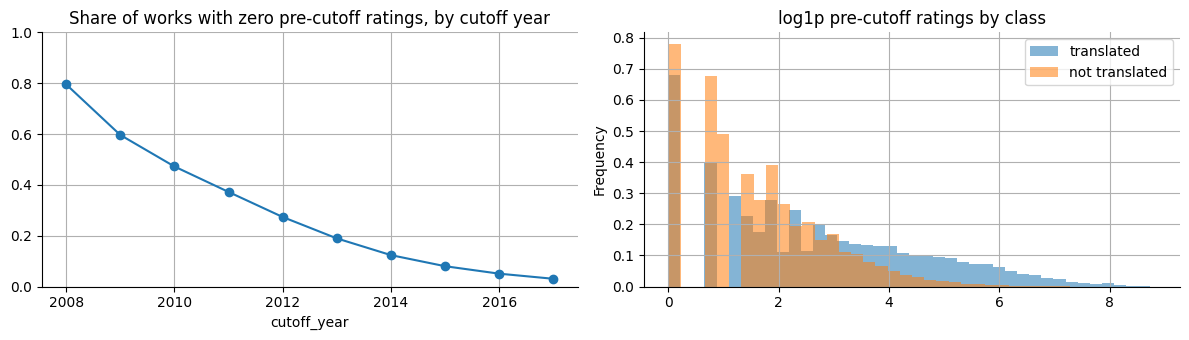

In [12]:
m = labels[["work_id", "translated_cz"]].merge(stats, on="work_id", how="left")
m["pre_cutoff_ratings_count"] = m["pre_cutoff_ratings_count"].fillna(0)
m["zero"] = m["pre_cutoff_ratings_count"] == 0

print(f"Zero pre-cutoff ratings overall : {m['zero'].mean():.1%}")
print(m.groupby("translated_cz")["zero"].mean().rename("zero_share").round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
m.groupby("cutoff_year")["zero"].mean().plot(marker="o", ax=axes[0])
axes[0].set_title("Share of works with zero pre-cutoff ratings, by cutoff year")
axes[0].set_ylim(0, 1)

for val, name in [(1, "translated"), (0, "not translated")]:
    np.log1p(m.loc[m["translated_cz"] == val, "pre_cutoff_ratings_count"])\
        .plot(kind="hist", bins=40, alpha=0.55, density=True, ax=axes[1], label=name)
axes[1].legend()
axes[1].set_title("log1p pre-cutoff ratings by class")
plt.tight_layout()
plt.show()

## Step 7 — Final dataset + temporal split

`src/features/build_features.py` merges labels and pre-cutoff stats and derives the features:

- **popularity**: pre-cutoff ratings count (+ log), avg rating (imputed 3.5 when absent), `has_precutoff_signal` (≥ 5 ratings), log text reviews
- **genre**: 7 shelf-bucket shares · **language**: dummies eng/ger/fre/spa/ita/swe · **age**: `age_at_cutoff`

`cutoff_year` is the **split key only**, excluded from X (under a temporal split every val/test year is unseen — a model could only extrapolate on it).

Split: **train ≤ 2015 | val = 2016 | test = 2017**. The test split stays sealed until the single final evaluation.

In [13]:
run_step(
    "src/features/build_features.py",
    ["data/processed/dataset.csv", "data/processed/splits/X_train.csv"],
    force=True,  # cheap (seconds) — always rebuild from current inputs
)

ds = pd.read_csv(REPO / "data/processed/dataset.csv", dtype={"work_id": str, "rep_book_id": str})
from src.features.build_features import feature_cols  # noqa: E402
fcols = feature_cols(ds)
print(f"\n{len(ds):,} rows | {len(fcols)} features: {fcols}")

RUN  src/features/build_features.py (forced)


Dataset: 419,716 rows, 11,274 positives (2.69%)
Features (19): ['shelf_fiction', 'shelf_mystery', 'shelf_romance', 'shelf_scifi', 'shelf_nonfiction', 'shelf_ya', 'shelf_classics', 'pre_cutoff_ratings_count', 'pre_cutoff_avg_rating', 'log_pre_cutoff_ratings_count', 'log_pre_cutoff_text_reviews', 'has_precutoff_signal', 'age_at_cutoff', 'lang_eng', 'lang_ger', 'lang_fre', 'lang_spa', 'lang_ita', 'lang_swe']

  train :  242,331 rows |  8,712 pos (3.60%) | years 2008-2015
  val   :   74,091 rows |  1,232 pos (1.66%) | years 2016-2016
  test  :  103,294 rows |  1,330 pos (1.29%) | years 2017-2017

→ /home/firstone/Bachelors-thesis/data/processed/dataset.csv
→ /home/firstone/Bachelors-thesis/data/processed/splits/X_*.csv, y_*.csv



419,716 rows | 19 features: ['shelf_fiction', 'shelf_mystery', 'shelf_romance', 'shelf_scifi', 'shelf_nonfiction', 'shelf_ya', 'shelf_classics', 'pre_cutoff_ratings_count', 'pre_cutoff_avg_rating', 'log_pre_cutoff_ratings_count', 'log_pre_cutoff_text_reviews', 'has_precutoff_signal', 'age_at_cutoff', 'lang_eng', 'lang_ger', 'lang_fre', 'lang_spa', 'lang_ita', 'lang_swe']


## Dataset analysis

Final checks before any modeling:

1. **Positive rate by year** — should be roughly stable; a drift would mean the split years differ structurally from training years.
2. **Feature ↔ label correlations** — a first, crude view of where the signal is.
3. **Class-conditional feature distributions** — do translated books actually look different?
4. **Split summary** — sizes and positive rates of train/val/test.

               rows  positives  pos_rate
cutoff_year                             
2008          14681        940    0.0640
2009          17209       1008    0.0586
2010          19483       1035    0.0531
2011          24546       1171    0.0477
2012          28610       1125    0.0393
2013          35213       1123    0.0319
2014          44471       1144    0.0257
2015          58118       1166    0.0201
2016          74091       1232    0.0166
2017         103294       1330    0.0129


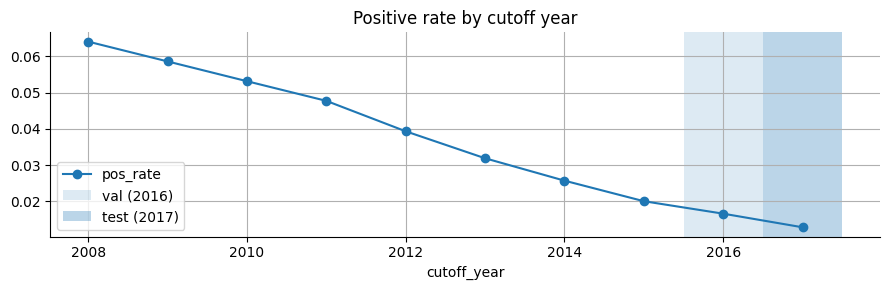

In [14]:
by_year = ds.groupby("cutoff_year")["translated_cz"].agg(["size", "sum", "mean"])
by_year.columns = ["rows", "positives", "pos_rate"]
print(by_year.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 3))
by_year["pos_rate"].plot(marker="o", ax=ax)
ax.axvspan(2015.5, 2016.5, alpha=0.15, label="val (2016)")
ax.axvspan(2016.5, 2017.5, alpha=0.3, label="test (2017)")
ax.set_title("Positive rate by cutoff year")
ax.legend()
plt.tight_layout()
plt.show()

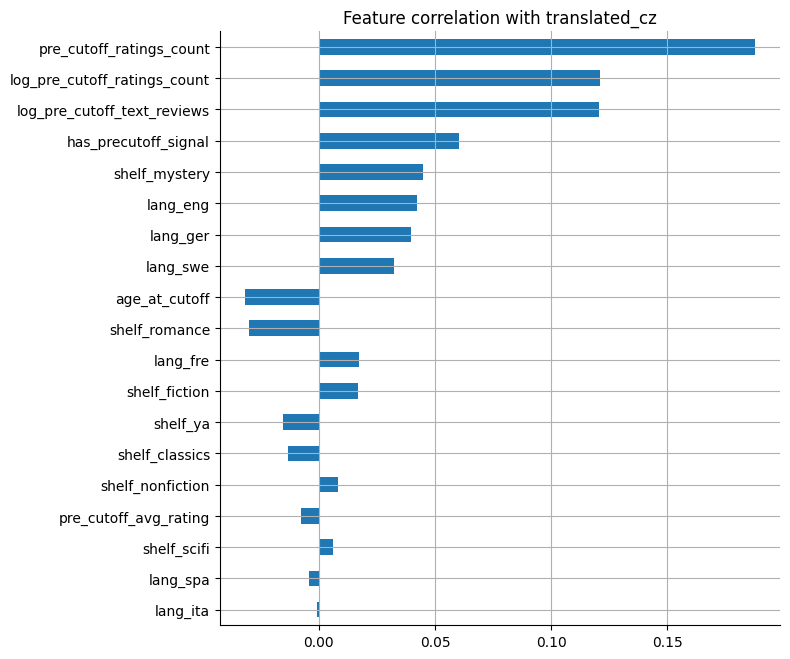

In [15]:
corrs = ds[fcols + ["translated_cz"]].corr()["translated_cz"].drop("translated_cz")
corrs = corrs.reindex(corrs.abs().sort_values().index)

fig, ax = plt.subplots(figsize=(8, 0.3 * len(corrs) + 1))
corrs.plot(kind="barh", ax=ax)
ax.set_title("Feature correlation with translated_cz")
plt.tight_layout()
plt.show()

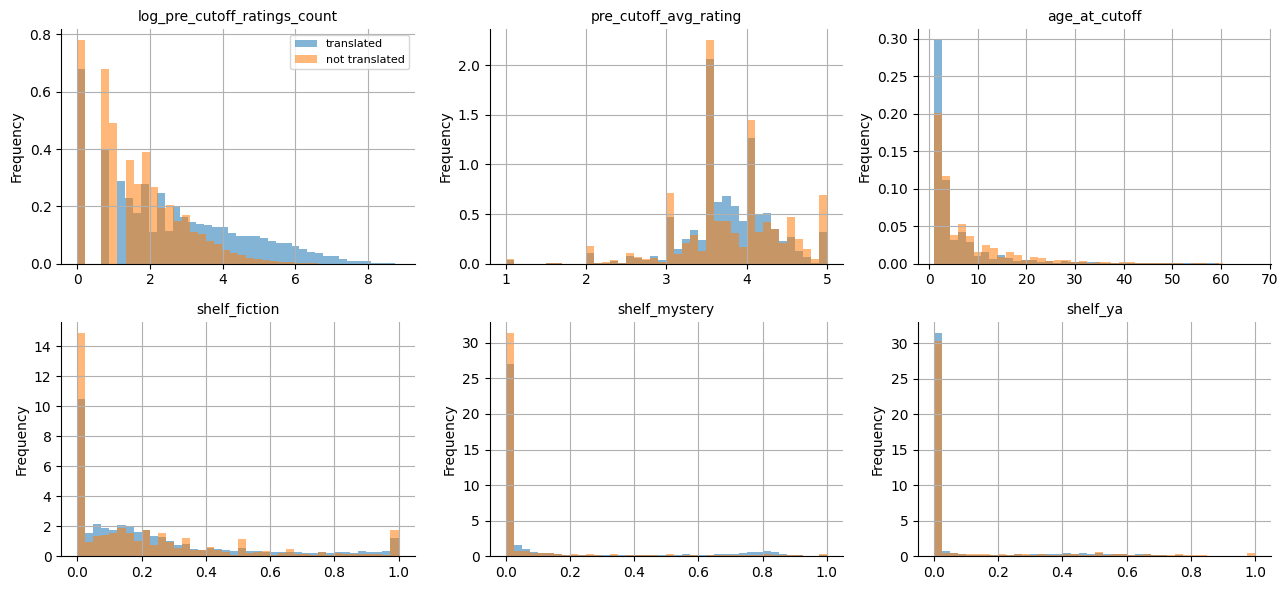

In [16]:
show = ["log_pre_cutoff_ratings_count", "pre_cutoff_avg_rating",
        "age_at_cutoff", "shelf_fiction", "shelf_mystery", "shelf_ya"]
show = [c for c in show if c in ds.columns]

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.ravel(), show):
    for val, name in [(1, "translated"), (0, "not translated")]:
        ds.loc[ds["translated_cz"] == val, col].plot(
            kind="hist", bins=40, alpha=0.55, density=True, ax=ax, label=name)
    ax.set_title(col, fontsize=10)
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [17]:
print("Split summary:")
rows = []
for name in ("train", "val", "test"):
    y = pd.read_csv(REPO / f"data/processed/splits/y_{name}.csv")["translated_cz"]
    rows.append({"split": name, "n": len(y), "positives": int(y.sum()),
                 "pos_rate": round(y.mean(), 4)})
print(pd.DataFrame(rows).to_string(index=False))

Split summary:
split      n  positives  pos_rate
train 242331       8712    0.0360
  val  74091       1232    0.0166
 test 103294       1330    0.0129


## Where this leaves us

The dataset is built: one row per foreign Goodreads work, leakage-free pre-cutoff features, `translated_cz` label, temporal split in `data/processed/splits/`.

**Known limitations (for the thesis text):**

1. **Negative-label noise** — ~75% of NKC translation records don't match to Goodreads, so some negatives were actually translated. Main caveat of this design.
2. **2017 snapshot** — features and labels end in 2017; no realistic refresh (Goodreads API shut down in 2020).
3. **Pre-cutoff sparsity** — works translated shortly after publication have little review history at cutoff (quantified in Step 6).
4. **Pool conditioning** — the model only ranks books findable on Goodreads with ≥ 50 ratings.

**Next (separate stage):** baselines (popularity-only, class-balanced logistic regression), then a gradient-boosting ranker; headline metrics PR-AUC and precision/lift@K on val (2016); test (2017) evaluated once at the very end.